# 2024101026 SMAI A1

In [15]:
%pip install numpy pandas matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.


In [17]:
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import erfinv
import seaborn as sns
from collections import Counter


username = 'ayush.aga'
seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
print(seed)

152369566


# 1. Automated Essay Scoring System

first reading the dataset and trying to find a starting pattern

In [20]:
df = pd.read_csv("essays.csv")

print(f"\nScore distribution:\n{df['score'].value_counts().sort_index()}")


Score distribution:
score
1    1252
2    4723
3    6280
4    3926
5     970
6     156
Name: count, dtype: int64


## 1.1 Feature Engineering

In [24]:
class EssayFeatureExtractor:
    """Extracts handcrafted statistical features from raw essay text"""

    # length-category thresholds
    SHORT_WORD_MAX = 3 #word length in characters
    MEDIUM_WORD_MAX = 6
    SHORT_SENT_MAX = 7 #sentence length in words
    MEDIUM_SENT_MAX = 20
    #large sentence and words done need a threshold btw

    def __init__(self):
        """Initialize the feature extractor."""
        pass

    def _words(self, essay: str) -> list:
        """Tokenize an essay into lowercase words"""
        words = []
        current_word = ""

        for char in essay.lower():
            if ("a" <= char <= "z") or char == "'":
                current_word += char
            else:
                if current_word:
                    words.append(current_word)
                    current_word = ""

        # add the last word if the essay does not end with punctuation/space
        if current_word:
            words.append(current_word)

        return words


    def _sentences(self, essay: str) -> list:
        """Split an essay into non-empty sentences using . ! ? as boundaries."""
        sentences = []
        current_sentence = ""

        for char in essay:
            if char in ".!?":
                if current_sentence.strip():
                    sentences.append(current_sentence.strip())
                current_sentence = ""
            else:
                current_sentence += char

        # add final sentence if there is no punctuation at the end
        if current_sentence.strip():
            sentences.append(current_sentence.strip())

        return sentences

    def extract_features(self, essay: str) -> dict:
        """Extract all handcrafted features from a single essay."""
        words = self._words(essay)
        sentences = self._sentences(essay)
        n_words = len(words)
        n_sents = len(sentences)

        word_lengths = np.array([len(w) for w in words])
        sent_lengths = np.array([len(self._words(s)) for s in sentences])
        word_counts = Counter(words)

        return {
            # length / fluency
            "num_words": n_words,
            "num_sentences": n_sents,
            "num_chars": len(essay),
            # word-length profile
            "num_short_words": int((word_lengths <= self.SHORT_WORD_MAX).sum()),
            "num_medium_words": int(((word_lengths > self.SHORT_WORD_MAX)
                                     & (word_lengths <= self.MEDIUM_WORD_MAX)).sum()),
            "num_long_words": int((word_lengths > self.MEDIUM_WORD_MAX).sum()),
            # sentence-length profile
            "num_short_sentences": int((sent_lengths <= self.SHORT_SENT_MAX).sum()),
            "num_medium_sentences": int(((sent_lengths > self.SHORT_SENT_MAX)
                                         & (sent_lengths <= self.MEDIUM_SENT_MAX)).sum()),
            "num_long_sentences": int((sent_lengths > self.MEDIUM_SENT_MAX).sum()),
            # complexity
            "avg_word_length": float(word_lengths.mean()),
            "avg_sentence_length": float(sent_lengths.mean()),
            "std_sentence_length": float(sent_lengths.std()),
            # vocabulary richness
            "type_token_ratio": len(word_counts) / n_words, #the number of type of tokens
            "hapax_ratio": (sum(1 for c in word_counts.values() if c == 1) / n_words
                            if n_words else 0.0), # the number of unique words only (occurs only once)
            # mechanics / structure
            "avg_commas_per_sentence": essay.count(",") / n_sents if n_sents else 0.0,
        }

    def extract_dataset_features(self, essays) -> pd.DataFrame:
        """Extract features for all essays; returns one row per essay."""
        return pd.DataFrame([self.extract_features(e) for e in essays])

In [27]:
# Sanity-check on one essay, then extract features for the whole dataset
extractor = EssayFeatureExtractor()

demo = extractor.extract_features(df["full_text"].iloc[0])
print("Features of essay 0:")
for name, value in demo.items():
    print(f"  {name} = {value}" if isinstance(value, float) else f"  {name} = {value}")

features_df = extractor.extract_dataset_features(df["full_text"])
features_df["score"] = df["score"].values

print(f"\nFeature matrix shape: {features_df.shape}")
features_df.describe().T.round(3)

Features of essay 0:
  num_words = 498
  num_sentences = 13
  num_chars = 2677
  num_short_words = 212
  num_medium_words = 214
  num_long_words = 72
  num_short_sentences = 1
  num_medium_sentences = 3
  num_long_sentences = 9
  avg_word_length = 4.244979919678715
  avg_sentence_length = 38.30769230769231
  std_sentence_length = 31.682037170768247
  type_token_ratio = 0.4457831325301205
  hapax_ratio = 0.2971887550200803
  avg_commas_per_sentence = 1.0769230769230769

Feature matrix shape: (17307, 16)


,count,mean,std,min,25%,50%,75%,max
num_words,17307.0,367.058,149.997,150.000,253.000,343.000,451.000,1656.000
num_sentences,17307.0,19.879,8.835,1.000,13.000,19.000,25.000,135.000
num_chars,17307.0,2063.686,924.106,712.000,1390.500,1916.000,2531.000,20450.000
num_short_words,17307.0,149.766,62.094,45.000,103.000,139.000,184.000,792.000
num_medium_words,17307.0,148.406,61.051,34.000,102.000,139.000,183.000,708.000
num_long_words,17307.0,68.886,36.378,2.000,42.000,61.000,88.000,386.000
num_short_sentences,17307.0,1.882,2.636,0.000,0.000,1.000,3.000,93.000
num_medium_sentences,17307.0,11.276,6.593,0.000,6.000,11.000,15.000,50.000
num_long_sentences,17307.0,6.721,4.098,0.000,4.000,6.000,9.000,48.000
avg_word_length,17307.0,4.432,0.293,3.438,4.228,4.430,4.635,5.667


## 1.2 Dataset Preprocessing

#### 1.2.1 Train-Validation-Test Split (80:10:10)

In [ ]:
# using the method given in assignment
rng = np.random.default_rng(seed)
print(rng)
indices = np.arange(len(features_df))
rng.shuffle(indices)
n = len(features_df)

train_end = int(0.8 * n)
val_end = int(0.9 * n)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X = features_df.drop(columns=["score"])
y = features_df["score"]

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Generator(PCG64)
Training samples: 13845
Validation samples: 1731
Test samples: 1731


### 1.2.2 Feature Normalization

In [ ]:
# Learn normalization parameters only from training data
train_mean = X_train.mean()
train_std = X_train.std()

# Avoid division by zero in case any feature is constant (safe guard only, doesnt mess stuff up)
train_std = train_std.replace(0, 1)

# Apply the same training statistics everywhere
X_train_norm = (X_train - train_mean) / train_std
X_val_norm = (X_val - train_mean) / train_std
X_test_norm = (X_test - train_mean) / train_std

print(X_train_norm.mean())
print(X_train_norm.std())

num_words                  5.029483e-17
num_sentences             -1.005897e-16
num_chars                 -3.528336e-17
num_short_words            6.055908e-17
num_medium_words          -1.298428e-16
num_long_words            -5.953265e-17
num_short_sentences        1.488316e-17
num_medium_sentences       1.315107e-16
num_long_sentences        -2.309456e-17
avg_word_length           -1.732349e-15
avg_sentence_length        1.768017e-16
std_sentence_length        3.695130e-17
type_token_ratio          -1.785980e-16
hapax_ratio                3.012558e-16
avg_commas_per_sentence    2.032322e-16
dtype: float64
num_words                  1.0
num_sentences              1.0
num_chars                  1.0
num_short_words            1.0
num_medium_words           1.0
num_long_words             1.0
num_short_sentences        1.0
num_medium_sentences       1.0
num_long_sentences         1.0
avg_word_length            1.0
avg_sentence_length        1.0
std_sentence_length        1.0
type_token_ra

### 1.2.3 Feature Visualization

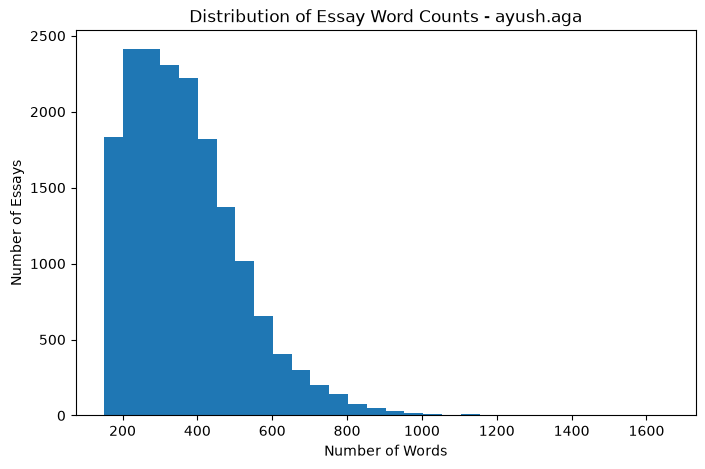

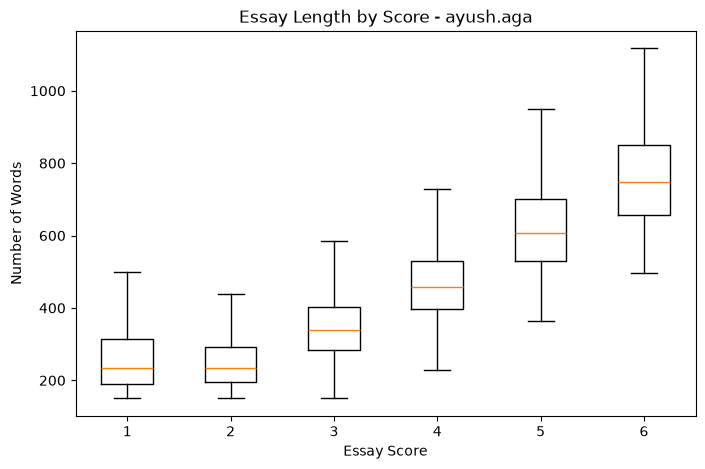

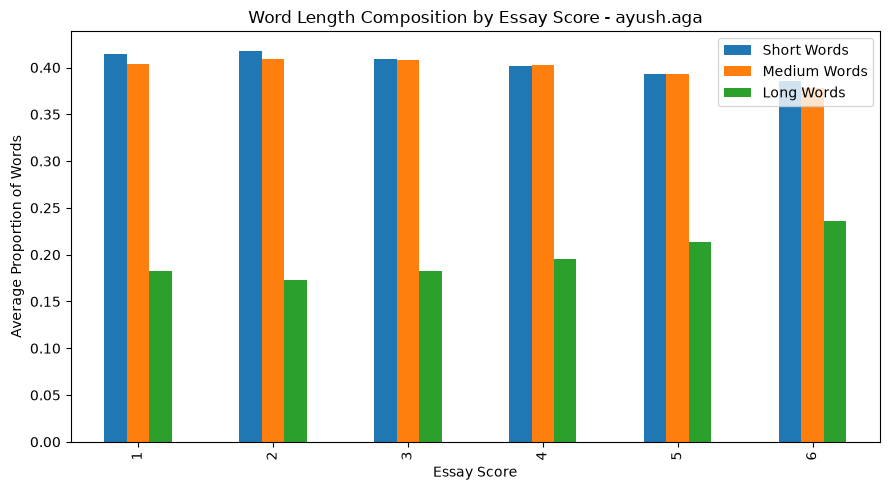

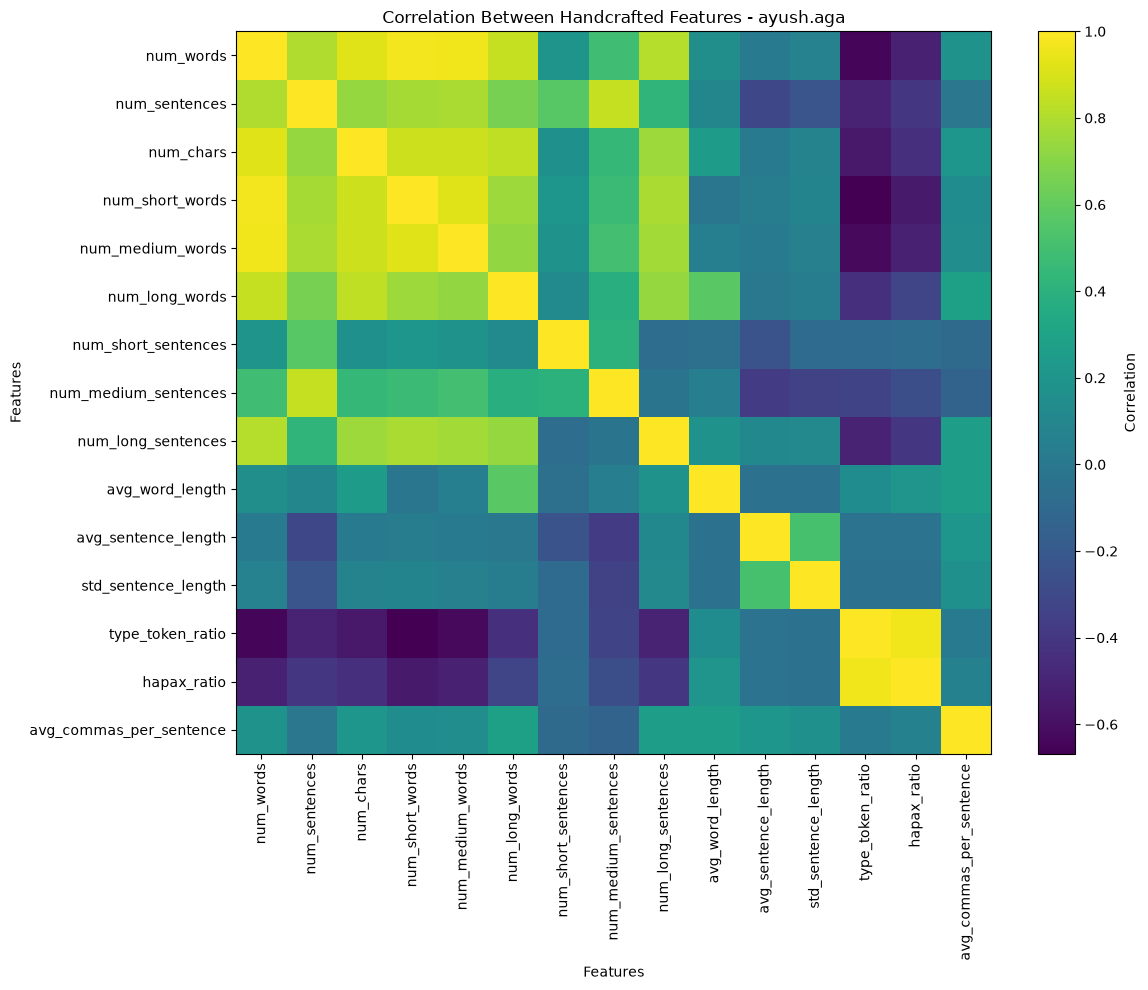

In [ ]:
# 1: histogram of essay word counts
plt.figure(figsize=(8, 5))

plt.hist(features_df["num_words"], bins=30)

plt.title(f"Distribution of Essay Word Counts - {username}")
plt.xlabel("Number of Words")
plt.ylabel("Number of Essays")

plt.show()

# 2: Essay length by score
plt.figure(figsize=(8, 5))

scores = sorted(features_df["score"].unique())

data_by_score = [
    features_df[features_df["score"] == score]["num_words"]
    for score in scores
]

plt.boxplot(
    data_by_score,
    tick_labels=scores,
    showfliers=False
)

plt.title(f"Essay Length by Score - {username}")
plt.xlabel("Essay Score")
plt.ylabel("Number of Words")

plt.show()

# 3: Word length composition by score
plot_df = features_df.copy()

plot_df["short_word_prop"] = (
    plot_df["num_short_words"] / plot_df["num_words"]
)

plot_df["medium_word_prop"] = (
    plot_df["num_medium_words"] / plot_df["num_words"]
)

plot_df["long_word_prop"] = (
    plot_df["num_long_words"] / plot_df["num_words"]
)

word_props_by_score = plot_df.groupby("score")[
    ["short_word_prop", "medium_word_prop", "long_word_prop"]
].mean()

word_props_by_score.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(f"Word Length Composition by Essay Score - {username}")
plt.xlabel("Essay Score")
plt.ylabel("Average Proportion of Words")
plt.legend(["Short Words", "Medium Words", "Long Words"])

plt.tight_layout()
plt.show()

# 4: Correlation heatmap
feature_only_df = features_df.drop(columns=["score"])

correlation_matrix = feature_only_df.corr()

plt.figure(figsize=(12, 10))

plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title(f"Correlation Between Handcrafted Features - {username}")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

## 1.3 K-Nearest Neighbors

### 1.3.1 Implementation

In [41]:
class KNN:
    def __init__(self, k=5, distance="euclidean"):
        """Initialize the KNN regression model."""
        self.k = k
        self.distance = distance
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """Store the training features and target scores."""
        self.X_train = np.asarray(X_train)
        self.y_train = np.asarray(y_train)

    def _compute_distance(self, x1, x2):
        """Compute distance between two feature vectors."""
        if self.distance == "euclidean":
            return np.sqrt(np.sum((x1 - x2) ** 2))

        elif self.distance == "manhattan":
            return np.sum(np.abs(x1 - x2))

        elif self.distance == "cosine":
            denominator = np.linalg.norm(x1) * np.linalg.norm(x2)

            if denominator == 0:
                return 1.0

            cosine_similarity = np.dot(x1, x2) / denominator
            return 1 - cosine_similarity

        else:
            raise ValueError("Unsupported distance metric")

    def predict(self, X):
        """Predict essay scores for the given feature vectors."""
        X = np.asarray(X)

        predictions = []

        for x in X:
            distances = []

            for train_x in self.X_train:
                d = self._compute_distance(x, train_x)
                distances.append(d)

            distances = np.array(distances)

            nearest_indices = np.argsort(distances)[:self.k]

            nearest_scores = self.y_train[nearest_indices]

            prediction = np.mean(nearest_scores)
            predictions.append(prediction)

        return np.array(predictions)

### 1.3.2 Hyperparamether tuning

In [44]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
distance_metrics = ["euclidean", "manhattan", "cosine"]

results = []

def mean_absolute_error(y_true, y_pred):
    """Compute mean absolute error."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(np.abs(y_true - y_pred))

for distance in distance_metrics:
    for k in k_values:

        model = KNN(k=k, distance=distance)
        model.fit(X_train_norm, y_train)

        y_val_pred = model.predict(X_val_norm)

        mae = mean_absolute_error(y_val, y_val_pred)

        results.append({
            "distance": distance,
            "k": k,
            "validation_mae": mae
        })

        print(distance, k, mae)

results_df = pd.DataFrame(results)
results_df

# smaller test (takes about a minute to run)
# model = KNN(k=5, distance="euclidean")
# model.fit(X_train_norm, y_train)

# y_val_pred = model.predict(X_val_norm)

# print(mean_absolute_error(y_val, y_val_pred))

euclidean 1 0.6320046216060081
euclidean 3 0.5701906412478336
euclidean 5 0.5462738301559792
euclidean 7 0.5383345712635141
euclidean 9 0.5332819821554657
euclidean 11 0.5283861141746757
euclidean 15 0.521471211245908
euclidean 21 0.5185276883717093
manhattan 1 0.6268053148469093
manhattan 3 0.576160215674947
manhattan 5 0.546735990756788
manhattan 7 0.5322274490385408
manhattan 9 0.5267988959496759
manhattan 11 0.5200882306601544
manhattan 15 0.5163874446370114
manhattan 21 0.5126131330637396
cosine 1 0.6678220681686886
cosine 3 0.5884844983631813
cosine 5 0.5569035239745812
cosine 7 0.5488157134604275
cosine 9 0.5498427370177803
cosine 11 0.5489207499606112
cosine 15 0.5425765453495089
cosine 21 0.5368490550466287


,distance,k,validation_mae
0,euclidean,1,0.632005
1,euclidean,3,0.570191
2,euclidean,5,0.546274
3,euclidean,7,0.538335
4,euclidean,9,0.533282
5,euclidean,11,0.528386
6,euclidean,15,0.521471
7,euclidean,21,0.518528
8,manhattan,1,0.626805
9,manhattan,3,0.576160


actually finding the best model, and using it

In [45]:
results_df = pd.DataFrame(results)

best_row = results_df.loc[results_df["validation_mae"].idxmin()]

best_k = int(best_row["k"])
best_distance = best_row["distance"]

print("Best k:", best_k)
print("Best distance:", best_distance)
print("Best validation MAE:", best_row["validation_mae"])

best_model = KNN(k=best_k, distance=best_distance)
best_model.fit(X_train_norm, y_train)

y_test_pred = best_model.predict(X_test_norm)

Best k: 21
Best distance: manhattan
Best validation MAE: 0.5126131330637396


## 1.4 Evaluation

In [46]:
# 1.4.1 Mean Absolute Error
def mean_absolute_error(y_true, y_pred):
    """Compute Mean Absolute Error."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.mean(np.abs(y_true - y_pred))

# 1.4.2 Root Mean Squared Error
def root_mean_squared_error(y_true, y_pred):
    """Compute Root Mean Squared Error."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.sqrt(np.mean((y_true - y_pred) ** 2))

#1.4.3 R^2 Score
def r2_score(y_true, y_pred):
    """Compute R^2 Score."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - (ss_res / ss_tot)

#1.4.4 Pearson Correlation Coefficient
def pearson_correlation(y_true, y_pred):
    """Compute Pearson correlation coefficient."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_mean = np.mean(y_true)
    pred_mean = np.mean(y_pred)

    numerator = np.sum((y_true - true_mean) * (y_pred - pred_mean))

    denominator = np.sqrt(
        np.sum((y_true - true_mean) ** 2)*np.sum((y_pred - pred_mean) ** 2))
    if denominator == 0:
        return 0.0
    return numerator / denominator

mae = mean_absolute_error(y_test, y_test_pred)
rmse = root_mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
pearson = pearson_correlation(y_test, y_test_pred)

print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R^2:", r2)
print("Test Pearson Correlation:", pearson)


Test MAE: 0.5194905229567275
Test RMSE: 0.6832798002214912
Test R^2: 0.5614120345434501
Test Pearson Correlation: 0.75009527830027


# 2. Probability Basics and Bayesian Learning

## 2.1 A Sampling Toolkit From Scratch

### 2.1.1 Uniform Generator (LCG)

In [56]:
def lcg_uniform_generator(low, high, num_samples, seed):
    """Generate pseudo-random uniform samples using the MINSTD LCG."""
    a = 48271
    m = 2**31 - 1
    state = seed % m

    if state == 0:
        state = 1

    samples = []
    for _ in range(num_samples):
        state = (a * state) % m
        u = state / m
        value = low + u * (high - low)
        samples.append(value)

    return np.array(samples)

### 2.1.2 Gaussian Sampler

In [57]:
from scipy.special import erfinv

In [58]:
# b) inverse_cdf_gaussian(y, mu, sigma) implementation
def inverse_cdf_gaussian(y, mu, sigma):
    """Compute the inverse Gaussian CDF."""
    y = np.asarray(y)
    return mu + sigma * np.sqrt(2) * erfinv(2 * y - 1)

# c) gaussian_generator(mu, sigma, num_samples, seed) implementation
def gaussian_generator(mu, sigma, num_samples, seed):
    """Generate Gaussian samples using inverse CDF sampling."""
    uniform_samples = lcg_uniform_generator(0, 1, num_samples, seed)
    return inverse_cdf_gaussian(uniform_samples, mu, sigma)

### 2.1.3 Binomial Sampler

In [59]:
from scipy.special import comb

In [60]:
# a) binomial_quantile(k, n, p) implementation
def binomial_pmf(k, n, p):
    """Compute the Binomial PMF at k."""
    if k < 0 or k > n:
        return 0.0

    return float(
        comb(n, k) *
        (p ** k) *
        ((1 - p) ** (n - k))
    )

# b) binomial_quantile(y, n, p) implementation
def binomial_quantile(y, n, p):
    """Compute the Binomial quantile for probability y."""

    pmf_values = np.array([
        binomial_pmf(k, n, p)
        for k in range(n + 1)
    ])

    cdf_values = np.cumsum(pmf_values)

    return int(np.searchsorted(cdf_values, y))

#c) binomial_generator(n, p, num_samples, seed) implementation
def binomial_generator(n, p, num_samples, seed):
    """Generate Binomial samples using inverse CDF sampling."""
    uniform_samples = lcg_uniform_generator(0, 1, num_samples, seed)
    samples = []

    for y in uniform_samples:
        samples.append(binomial_quantile(y, n, p))

    return np.array(samples)

### 2.1.4 Image Sampler

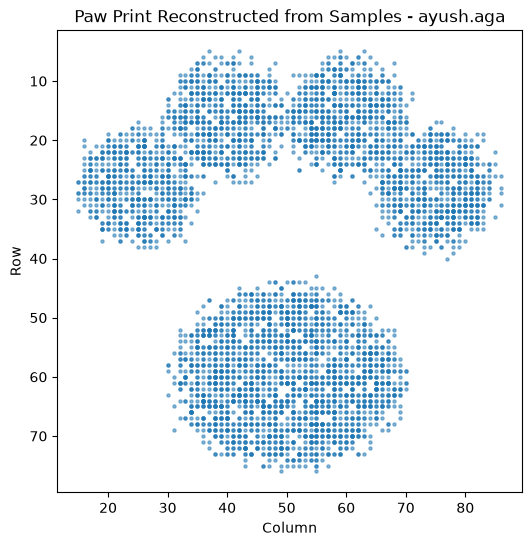

Image row marginal max CDF distance: 0.010402227518507057


In [61]:
# a) Row marginal + column conditional
def row_marginal(image):
    """Return the probability distribution over image rows."""
    image = np.asarray(image, dtype=float)

    row_sums = np.sum(image, axis=1)
    total = np.sum(row_sums)

    return row_sums / total

def col_conditional(image, row):
    """Return the conditional probability distribution over columns for a row."""
    image = np.asarray(image, dtype=float)

    row_values = image[row]
    row_total = np.sum(row_values)

    if row_total == 0:
        return np.zeros(len(row_values))

    return row_values / row_total

# b) Image generator
def image_generator(image, num_samples, seed):
    """Sample (row, col) coordinates from an image-based empirical density."""
    image = np.asarray(image, dtype=float)

    row_probs = row_marginal(image)
    row_cdf = np.cumsum(row_probs)

    uniform_samples = lcg_uniform_generator(
        0, 1, 2 * num_samples, seed
    )

    samples = []

    for i in range(num_samples):
        row_u = uniform_samples[2 * i]
        col_u = uniform_samples[2 * i + 1]

        row = np.searchsorted(row_cdf, row_u)

        col_probs = col_conditional(image, row)
        col_cdf = np.cumsum(col_probs)

        col = np.searchsorted(col_cdf, col_u)

        samples.append((row, col))

    return np.array(samples)

# c) Run it on the paw image
from PIL import Image

image = np.array(
    Image.open("paw_print.png").convert("L"),
    dtype=float
)

image_samples = image_generator(
    image,
    num_samples=5000,
    seed=seed
)

plt.figure(figsize=(6, 6))

plt.scatter(
    image_samples[:, 1],   # column
    image_samples[:, 0],   # row
    s=5,
    alpha=0.5
)

plt.gca().invert_yaxis()

plt.title(f"Paw Print Reconstructed from Samples - {username}")
plt.xlabel("Column")
plt.ylabel("Row")

plt.show()

# d) Validate sampled row marginal

sampled_rows = image_samples[:, 0]

true_row_probs = row_marginal(image)
true_row_cdf_values = np.cumsum(true_row_probs)

eval_rows = np.arange(image.shape[0])

def true_row_cdf(rows):
    rows = np.asarray(rows)

    values = []

    for row in rows:
        row = int(row)

        if row < 0:
            values.append(0.0)
        elif row >= len(true_row_cdf_values):
            values.append(1.0)
        else:
            values.append(true_row_cdf_values[row])

    return np.array(values)

image_row_distance = max_cdf_distance(
    sampled_rows,
    true_row_cdf,
    eval_rows
)

print("Image row marginal max CDF distance:", image_row_distance)

### 2.1.5 Generator Validation

In [62]:
def empirical_cdf(sample, x):
    """Compute empirical CDF values at evaluation points x."""
    sample = np.asarray(sample)
    x = np.asarray(x)

    values = []

    for t in x:
        values.append(
            np.mean(sample <= t)
        )

    return np.array(values)

def max_cdf_distance(sample, cdf_function, eval_points):
    """Compute maximum absolute gap between empirical and theoretical CDF."""
    empirical = empirical_cdf(sample, eval_points)
    theoretical = cdf_function(eval_points)

    return np.max(
        np.abs(empirical - theoretical)
    )


In [63]:

uniform_samples = lcg_uniform_generator(0, 1, 5000, seed)
uniform_eval = np.linspace(0, 1, 200)

def uniform_cdf(x):
    x = np.asarray(x)
    return np.where(x < 0, 0, np.where(x > 1, 1, x))

print(
    "Uniform max CDF distance:",
    max_cdf_distance(uniform_samples, uniform_cdf, uniform_eval)
)

from scipy.special import erf

mu = 0
sigma = 1

gaussian_samples = gaussian_generator(mu, sigma, 5000, seed)
gaussian_eval = np.linspace(-4, 4, 200)

def gaussian_cdf(x):
    x = np.asarray(x)
    return 0.5 * (
        1 + erf((x - mu) / (sigma * np.sqrt(2)))
    )

print(
    "Gaussian max CDF distance:",
    max_cdf_distance(gaussian_samples, gaussian_cdf, gaussian_eval)
)

n = 20
p = 0.4

binomial_samples = binomial_generator(n, p, 5000, seed)
binomial_eval = np.arange(0, n + 1)

def binomial_cdf(x):
    results = []

    for value in x:
        k_max = int(np.floor(value))
        total = 0.0

        for k in range(k_max + 1):
            total += binomial_pmf(k, n, p)

        results.append(total)

    return np.array(results)

print(
    "Binomial max CDF distance:",
    max_cdf_distance(binomial_samples, binomial_cdf, binomial_eval)
)

Uniform max CDF distance: 0.014911557788944707
Gaussian max CDF distance: 0.014372694101234207
Binomial max CDF distance: 0.011198725312224878
